# deep-memory-agent — LongMemEval-style benchmark

Measures the whole memory pipeline end to end, not a retriever over a frozen log.
Each case gets its own memory tree, its own agents and its own simulated clock:

```
<EXPERIMENT_ROOT>/<question_id>/memory/       the tree this case built
<EXPERIMENT_ROOT>/<question_id>/result.json   what this case produced
<EXPERIMENT_ROOT>/result.json                 config + every case + the summary
```

The run is resumable — a case that already has a `result.json` is not re-run — so
an interrupted run picks up where it stopped instead of paying twice.

**Before running the `large` scale, read the cost estimate cell.** Ingestion is one
agent invocation per session, and the `large` scale is ~48 sessions per case.

## 1. Configuration

Everything that defines a run. Nothing below this cell needs editing.

In [ ]:
from pathlib import Path

# --- where things live -------------------------------------------------------
BENCHMARK_DIR = (
    Path("benchmark").resolve() if Path("benchmark").exists() else Path.cwd()
)

from dma_bench.schema import CaseResult

EXPERIMENT_NAME = "small-longmemeval-10xC"
LONGMEMEVAL_DIR = BENCHMARK_DIR / "longmemeval" / "data"
OPERATIONAL_DIR = BENCHMARK_DIR / "data"
EXPERIMENT_ROOT = BENCHMARK_DIR / "runs" / EXPERIMENT_NAME

# --- what to run -------------------------------------------------------------
DATASET = "longmemeval"  # "longmemeval" | "operational"
SCALE = "small"  # "small" (oracle, ~2 sessions) | "large" (s, ~48 sessions)
N_PER_CATEGORY = 10  # cases sampled per category
CATEGORIES = None  # None = every category the corpus can supply
SEED = 0  # makes the sample reproducible

# --- how the memory is built -------------------------------------------------
CONSOLIDATION_MODE = "none"  # "none" | "periodic" | "final" | "periodic+final"
CONSOLIDATE_EVERY_N = 10  # sessions between periodic consolidations

# --- how it is graded --------------------------------------------------------
RECALL_THRESHOLD = 1.0  # 1.0 is LongMemEval's strict reading
CHAIN_OF_NOTE = True  # extract-then-reason answering prompt

# --- execution ---------------------------------------------------------------
MAX_WORKERS = 4  # cases graded concurrently; they share nothing
RECURSION_LIMIT = 60  # cap on agent steps per invocation
RESUME = True  # skip cases that already have a result.json

# --- models ------------------------------------------------------------------
# Any OpenAI-compatible endpoint: a local server (vLLM, LM Studio, llama.cpp),
# OpenRouter, or OpenAI itself. The judge should be at least as strong as the
# model under test — in the paper the judge is GPT-4o grading everything else.
AGENT_MODEL = "deepseek/deepseek-v4-flash-0731"
JUDGE_MODEL = "deepseek/deepseek-v4-flash-0731"  # "deepseek/deepseek-v4-pro-0813"
BASE_URL = "https://openrouter.ai/api/v1"  # None = OpenAI, else a local/OpenRouter URL
API_KEY = None  # None reads OPENAI_API_KEY from the environment
TEMPERATURE = 0.0
TIMEOUT = 240

## Utility functions


def load_summary(experiment_result: Path) -> dict:
    return json.loads(experiment_result.read_text())["summary"]


def load_result(experiment_result: Path) -> list[CaseResult]:
    list_dict_result = json.loads(experiment_result.read_text())["results"]
    return [CaseResult(**i) for i in list_dict_result]

## 2. Models

Factories, not instances: each case builds its own clients so nothing leaks between cases running side by side.

In [9]:
import os
import sys

if str(BENCHMARK_DIR) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_DIR))

from langchain_openai import ChatOpenAI

from dma_bench.runner import Runtime


def _model(name: str) -> ChatOpenAI:
    return ChatOpenAI(
        model=name,
        base_url=BASE_URL,
        api_key=API_KEY or os.environ.get("OPENAI_API_KEY", "not-needed"),
        temperature=TEMPERATURE,
        timeout=TIMEOUT,
        max_retries=2,
    )


runtime = Runtime(
    agent_model=lambda: _model(AGENT_MODEL),
    judge_model=lambda: _model(JUDGE_MODEL),
)
print(f"agent: {AGENT_MODEL}   judge: {JUDGE_MODEL}   endpoint: {BASE_URL or 'openai'}")

agent: deepseek/deepseek-v4-flash-0731   judge: deepseek/deepseek-v4-flash-0731   endpoint: https://openrouter.ai/api/v1


## 3. Load the cases

Sampling is balanced per category and reproducible for a given `SEED`.

In [10]:
from collections import Counter

from dma_bench.datasets import load_dataset
from dma_bench.schema import RunConfig

data_root = LONGMEMEVAL_DIR if DATASET == "longmemeval" else OPERATIONAL_DIR
cases = load_dataset(
    DATASET,
    data_root,
    scale=SCALE,
    categories=CATEGORIES,
    n_per_category=N_PER_CATEGORY,
    seed=SEED,
)

config = RunConfig(
    experiment_root=str(EXPERIMENT_ROOT),
    dataset=DATASET,
    scale=SCALE,
    n_per_category=N_PER_CATEGORY,
    consolidation_mode=CONSOLIDATION_MODE,
    consolidate_every_n=CONSOLIDATE_EVERY_N,
    recall_threshold=RECALL_THRESHOLD,
    chain_of_note=CHAIN_OF_NOTE,
    agent_model=AGENT_MODEL,
    judge_model=JUDGE_MODEL,
    max_workers=MAX_WORKERS,
    recursion_limit=RECURSION_LIMIT,
    seed=SEED,
    resume=RESUME,
)

print(f"{len(cases)} cases from {DATASET}/{SCALE}")
for name, count in sorted(Counter(case.category.value for case in cases).items()):
    print(f"  {name:22s} {count}")

12 cases from longmemeval/large
  abstention             2
  knowledge-update       2
  multi-hop              2
  preference             2
  single-hop             2
  temporal-reasoning     2


## 4. What this will cost

Ingestion dominates: one agent invocation per session, each several model calls
once tool use is counted. Read this before running the `large` scale.

In [11]:
from dma_bench.runner import estimate_run, iter_pending

estimate = estimate_run(cases, config)
pending = iter_pending(cases, config)

for key, value in estimate.items():
    print(f"{key:32s} {value:,}")
print(
    f"\n{len(pending)} of {len(cases)} cases still to run "
    f"({len(cases) - len(pending)} already have a result.json)"
)

cases                            12
sessions                         556
turns                            5,799
history_chars                    5,907,949
ingestion_invocations            556
consolidation_invocations        0
answer_invocations               12
judge_invocations                38
estimated_model_calls_low        1,174
estimated_model_calls_high       2,890

12 of 12 cases still to run (0 already have a result.json)


## 5. Run

Each finished case is written to disk as it completes, so stopping here loses nothing.

In [12]:
import itertools
import time

from dma_bench.runner import run_experiment

started = time.monotonic()
counter = itertools.count(1)


def progress(result):
    recall = result.retrieval.recall
    status = (
        "ERROR"
        if result.error
        else (
            f"qa={'Y' if result.qa.correct else 'n'} "
            f"recall={recall if recall is not None else '-'} "
            f"cons={'Y' if result.consolidation.correct else 'n'}"
        )
    )
    print(
        f"[{next(counter):3d}/{len(cases)}] {result.question_id:24s} "
        f"{result.category.value:22s} {status}  "
        f"({time.monotonic() - started:.0f}s)"
    )


experiment = run_experiment(cases, config, runtime, on_result=progress)
print(f"\nwrote {EXPERIMENT_ROOT / 'result.json'}")

[  1/12] 2133c1b5_abs             abstention             qa=Y recall=- cons=n  (4297s)
[  2/12] f685340e_abs             abstention             qa=Y recall=- cons=n  (4297s)
[  3/12] 184da446                 knowledge-update       qa=n recall=0.0 cons=n  (4297s)
[  4/12] 6071bd76                 knowledge-update       qa=Y recall=1.0 cons=n  (4297s)
[  5/12] 3a704032                 multi-hop              qa=Y recall=1.0 cons=n  (11911s)
[  6/12] 8e91e7d9                 multi-hop              qa=Y recall=1.0 cons=n  (11911s)
[  7/12] 1d4e3b97                 preference             qa=Y recall=1.0 cons=Y  (11911s)
[  8/12] 75f70248                 preference             qa=n recall=1.0 cons=n  (11911s)
[  9/12] 311778f1                 single-hop             qa=Y recall=1.0 cons=n  (13747s)
[ 10/12] 51a45a95                 single-hop             qa=Y recall=0.0 cons=n  (13747s)
[ 11/12] 2a1811e2                 temporal-reasoning     qa=Y recall=1.0 cons=n  (13747s)
[ 12/12] bbf86515 

## 6. Results

In [21]:
import json

import pandas as pd

from dma_bench.report import category_table, cost_table, decomposition_table

pd.set_option("display.width", 140)
summary = load_summary(EXPERIMENT_ROOT / "result.json")

print(
    f"cases {summary['cases']}  failed {summary['failed_cases']}  "
    f"duration {summary.get('duration_s', 0)}s\n"
)
category_table(summary).round(3)

cases 60  failed 0  duration 299.2s



,n,QA accuracy,Retrieval correct,Retrieval recall,Consolidation correct,Superseded leak
category,,,,,,
abstention,10,0.900,0.333,0.333,0.800,NaN
knowledge-update,10,0.800,0.300,0.450,0.700,NaN
multi-hop,10,0.800,0.800,0.800,0.500,NaN
preference,10,0.700,0.400,0.400,0.700,NaN
single-hop,10,0.700,0.500,0.500,0.600,NaN
temporal-reasoning,10,0.500,0.700,0.700,0.700,NaN
supersede-integrity,10,0.800,0.300,0.450,0.700,0.0
ALL,60,0.733,0.528,0.557,0.667,NaN


### The three-stage decomposition

LongMemEval decomposes failures across two stages because it has two. A system
that writes its own memory has three, so this is eight cells rather than four —
and each cell names a different file to go and change.

In [22]:
summary = load_summary(EXPERIMENT_ROOT / "result.json")

decomposition_table(summary)

,count,share,points at
cell,,,
C✓ R✓ G✓,17,0.3208,working as intended
C✓ R✗ G✓,12,0.2264,answered without retrieving: check for paramet...
C✗ R✗ G✗,8,0.1509,consolidation: the fact never made it into memory
C✗ R✓ G✓,5,0.0943,judge disagreement: memory looked wrong but th...
C✗ R✗ G✓,4,0.0755,answered without memory: check for parametric ...
C✓ R✓ G✗,3,0.0566,reading strategy: the fact was in view and the...
C✗ R✓ G✗,3,0.0566,consolidation: what was written does not suppo...
C✓ R✗ G✗,1,0.0189,indexing and search: the fact is on file but w...


In [23]:
summary = load_summary(EXPERIMENT_ROOT / "result.json")

cost_table(summary)

,value
sessions_ingested,105.0
failed_sessions,0.0
write_calls,282.0
unsolicited_consolidations,0.0
consolidation_passes,0.0
active_entries,199.0
superseded_entries,19.0
ingestion_seconds,4457.9
answer_seconds,1286.9


## 7. Charts

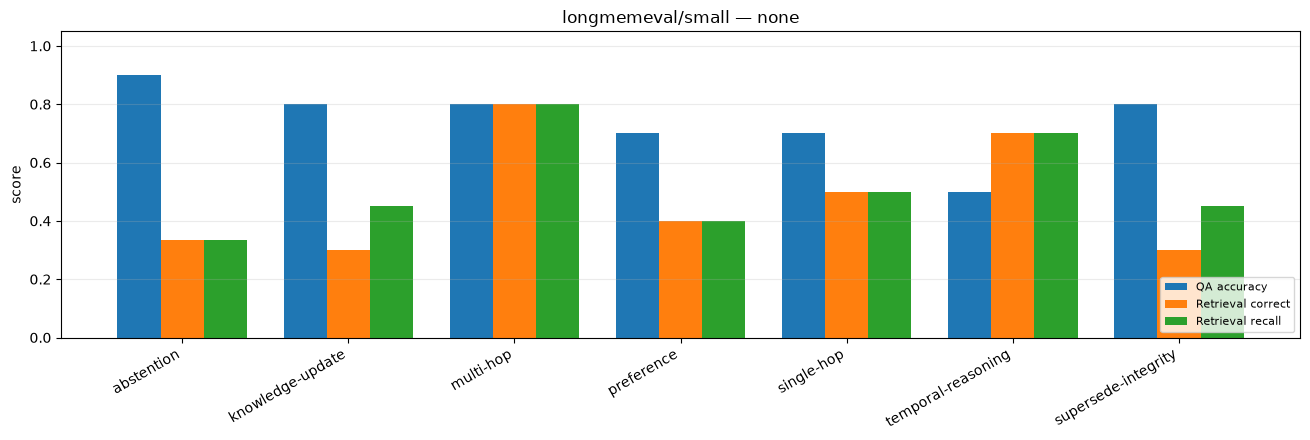

In [24]:
%matplotlib inline
summary = load_summary(EXPERIMENT_ROOT / "result.json")

from dma_bench.report import (
    plot_accuracy_by_category,
    plot_decomposition,
    plot_recall_vs_accuracy,
)

plot_accuracy_by_category(summary, title=f"{DATASET}/{SCALE} — {CONSOLIDATION_MODE}");

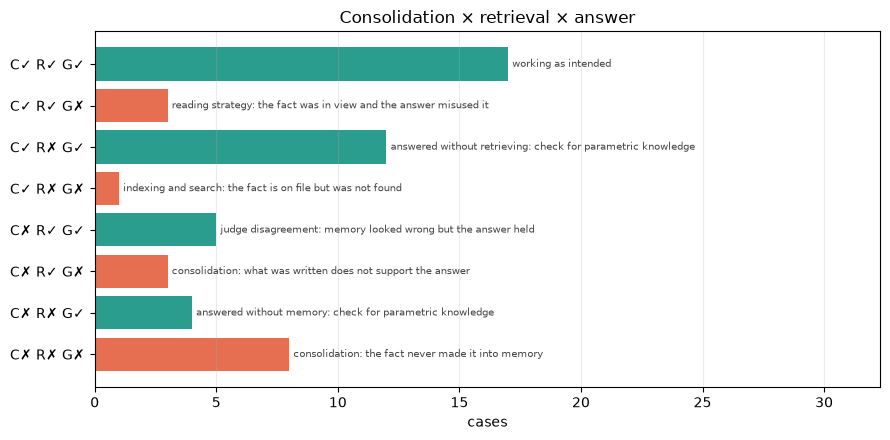

In [25]:
summary = load_summary(EXPERIMENT_ROOT / "result.json")

plot_decomposition(summary);

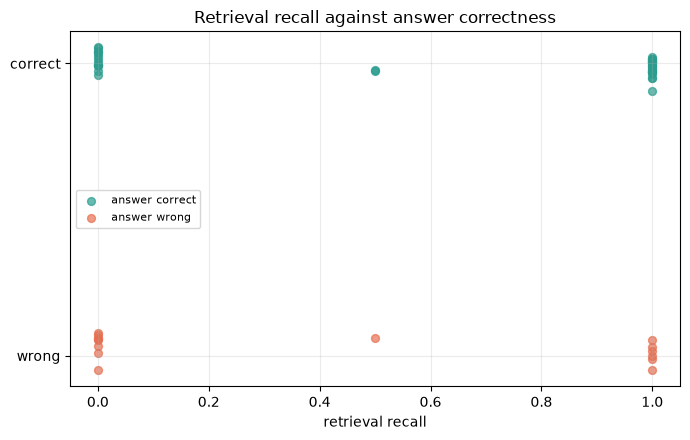

In [26]:
results = load_result(EXPERIMENT_ROOT / "result.json")
plot_recall_vs_accuracy(results);

## 8. Consolidation ablation

`consolidation-quality` is not a question category — it is the difference between
two runs over the same cases, one with consolidation and one without. Run this
after the cell above, with a second `EXPERIMENT_ROOT` so both stay on disk.

Skip it on the `small` scale: with two sessions per case there is nothing for a
consolidation pass to consolidate.

In [ ]:
ABLATION_MODES = ["none", "periodic+final"]


def load_summaries() -> dict:
    summaries = {}

    for mode in ABLATION_MODES:
        arm_dir = f"{EXPERIMENT_ROOT.name}-{mode.replace('+', '-')}"
        experiment_result = EXPERIMENT_ROOT.parent / arm_dir / "result.json"
        summaries[mode] = json.loads(experiment_result.read_text())["summary"]

    return summaries

In [ ]:
summaries = {}
for mode in ABLATION_MODES:
    arm_config = config.model_copy(
        update={
            "consolidation_mode": mode,
            "experiment_root": str(
                EXPERIMENT_ROOT.parent
                / f"{EXPERIMENT_ROOT.name}-{mode.replace('+', '-')}"
            ),
        }
    )
    print(f"\n=== arm: {mode} ===")
    arm = run_experiment(cases, arm_config, runtime, on_result=progress)
    summaries[mode] = arm.summary

pd.DataFrame(
    {
        mode: {
            "QA accuracy": values.get("qa_accuracy"),
            "Retrieval correct": values.get("retrieval_correct_rate"),
            "Retrieval recall": values.get("retrieval_recall"),
            "Consolidation correct": values.get("consolidation_correct_rate"),
            "Active entries": values.get("cost", {}).get("active_entries"),
            "Superseded entries": values.get("cost", {}).get("superseded_entries"),
        }
        for mode, values in summaries.items()
    }
).round(3)


=== arm: none ===
[ 19/18] 2133c1b5_abs             abstention             qa=Y recall=- cons=Y  (11204s)
[ 20/18] 2311e44b_abs             abstention             qa=Y recall=- cons=n  (11204s)
[ 21/18] gpt4_c27434e8_abs        abstention             qa=Y recall=1.0 cons=n  (11204s)
[ 22/18] 41698283                 knowledge-update       qa=Y recall=1.0 cons=n  (11204s)
[ 23/18] 603deb26                 knowledge-update       qa=Y recall=0.5 cons=Y  (11245s)
[ 24/18] cf22b7bf                 knowledge-update       qa=Y recall=0.5 cons=Y  (11278s)
[ 25/18] 46a3abf7                 multi-hop              qa=Y recall=1.0 cons=Y  (11332s)
[ 26/18] e3038f8c                 multi-hop              qa=n recall=0.75 cons=n  (11386s)
[ 27/18] e831120c                 multi-hop              qa=n recall=1.0 cons=n  (11386s)
[ 28/18] 06f04340                 preference             qa=n recall=0.0 cons=n  (11386s)
[ 29/18] 38146c39                 preference             qa=Y recall=1.0 cons=Y  (11

,none,periodic+final
QA accuracy,0.667,0.778
Retrieval correct,0.562,0.688
Retrieval recall,0.745,0.792
Consolidation correct,0.444,0.833
Active entries,57.000,74.000
Superseded entries,10.000,9.000


In [ ]:
from dma_bench.report import plot_ablation

summaries = load_summaries()

plot_ablation(summaries, title="Effect of consolidation on QA accuracy");

NameError: name 'load_summaries' is not defined

## 9. Reload a finished run

The results are complete on disk, so a report can be rebuilt without spending
anything. Point this at any experiment root.

In [13]:
from IPython.display import display

from dma_bench.report import category_table
from dma_bench.runner import load_experiment

for mode in ABLATION_MODES:
    arm_dir = f"{EXPERIMENT_ROOT.name}-{mode.replace('+', '-')}"
    experiment_path = EXPERIMENT_ROOT.parent / arm_dir

    reloaded = load_experiment(experiment_path)
    df = category_table(reloaded.summary).round(3)
    print(f"=== arm: {mode} ===")
    display(df)

# If a run was interrupted before result.json was written, the per-case files
# are still complete on their own:
#
#     from dma_bench.metrics import summarise
#     from dma_bench.runner import load_case_results
#
#     category_table(summarise(load_case_results(EXPERIMENT_ROOT))).round(3)

=== arm: none ===


,n,QA accuracy,Retrieval correct,Retrieval recall,Consolidation correct,Superseded leak
category,,,,,,
abstention,3,1.000,1.000,1.000,0.333,NaN
knowledge-update,3,1.000,0.333,0.667,0.667,NaN
multi-hop,3,0.333,0.667,0.917,0.333,NaN
preference,3,0.333,0.667,0.667,0.667,NaN
single-hop,3,1.000,1.000,1.000,0.667,NaN
temporal-reasoning,3,0.333,0.000,0.389,0.000,NaN
supersede-integrity,3,1.000,0.333,0.667,0.667,0.0
ALL,18,0.667,0.562,0.745,0.444,NaN


=== arm: periodic+final ===


,n,QA accuracy,Retrieval correct,Retrieval recall,Consolidation correct,Superseded leak
category,,,,,,
abstention,3,1.000,1.000,1.000,1.000,NaN
knowledge-update,3,0.667,0.333,0.667,1.000,NaN
multi-hop,3,1.000,1.000,1.000,1.000,NaN
preference,3,0.667,1.000,1.000,0.667,NaN
single-hop,3,0.667,0.667,0.667,0.667,NaN
temporal-reasoning,3,0.667,0.333,0.556,0.667,NaN
supersede-integrity,3,0.667,0.333,0.667,1.000,0.333
ALL,18,0.778,0.688,0.792,0.833,NaN
